# Exploratory Data Analysis

This notebook explores the project dataset to understand its structure, data quality, distributions, and relationships between the evaluation criteria used in the portfolio prioritization analysis.

## 1. Configure Project Path

The project root directory is added to the Python path to allow consistent access to project modules and directories.

In [49]:
import sys
from pathlib import Path

project_root = Path().resolve().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

## 2. Import Libraries

Pandas is used for data manipulation and analysis, while NumPy is used for numerical operations. Matplotlib and Seaborn are used to visualize the main characteristics of the dataset.

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load Dataset

The project dataset is loaded from the raw data directory.

In [51]:
df = pd.read_csv("../data/raw/projects.csv")

df.shape

(4000, 51)

## 4. Inspect Dataset

The first rows of the dataset are displayed to verify the data structure and confirm that the dataset was loaded correctly.

In [52]:
df.head()

,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High


## 5. Inspect Dataset Structure

The dataset structure is inspected to identify the number of observations, variables, and their respective data types.# 4. Missing and Duplicate values

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 51 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Project_ID                       4000 non-null   object 
 1   Project_Type                     4000 non-null   object 
 2   Team_Size                        4000 non-null   int64  
 3   Project_Budget_USD               4000 non-null   float64
 4   Estimated_Timeline_Months        4000 non-null   int64  
 5   Complexity_Score                 4000 non-null   float64
 6   Stakeholder_Count                4000 non-null   int64  
 7   Methodology_Used                 4000 non-null   object 
 8   Team_Experience_Level            4000 non-null   object 
 9   Past_Similar_Projects            4000 non-null   int64  
 10  External_Dependencies_Count      4000 non-null   int64  
 11  Change_Request_Frequency         4000 non-null   float64
 12  Project_Phase       

## 6. Check Missing Values

The dataset is checked for missing values to identify potential data quality issues before performing the prioritization analysis.

In [54]:
missing_values = df.isna().sum()

missing_values[
    missing_values > 0
].sort_values(
    ascending=False
)

Tech_Environment_Stability    2619
Risk_Management_Maturity       791
Change_Control_Maturity        780
dtype: int64

## 7. Check Duplicated Rows

The dataset is checked for duplicated observations to ensure that the project records are unique.

In [55]:
duplicated_rows = df.duplicated().sum()

print(
    "Number of duplicated rows:",
    duplicated_rows
)

Number of duplicated rows: 0


## 8. Define Evaluation Criteria

Six criteria are selected for the portfolio prioritization analysis. Each criterion represents a characteristic that can influence the attractiveness or feasibility of a project.

In [56]:
criteria_objectives = {
    "Project_Budget_USD": "min",
    "Estimated_Timeline_Months": "min",
    "Complexity_Score": "min",
    "Previous_Delivery_Success_Rate": "max",
    "Resource_Availability": "max",
    "Historical_Risk_Incidents": "min",
}

criteria_names = list(
    criteria_objectives.keys()
)

criteria_names

['Project_Budget_USD',
 'Estimated_Timeline_Months',
 'Complexity_Score',
 'Previous_Delivery_Success_Rate',
 'Resource_Availability',
 'Historical_Risk_Incidents']

## 9. Descriptive Statistics

Descriptive statistics are calculated for the selected evaluation criteria to understand their central tendency and dispersion.

In [57]:
criteria_stats = df[
    criteria_names
].describe().T

criteria_stats

,count,mean,std,min,25%,50%,75%,max
Project_Budget_USD,4000.0,1.143032e+06,590878.115350,159355.55,692532.915,1007471.805,1.475870e+06,3768354.37
Estimated_Timeline_Months,4000.0,1.714775e+01,6.926609,2.00,12.000,17.000,2.200000e+01,36.00
Complexity_Score,4000.0,6.192525e+00,2.212538,1.62,4.460,6.015,7.862500e+00,10.00
Previous_Delivery_Success_Rate,4000.0,7.504375e-01,0.143712,0.15,0.660,0.770,8.600000e-01,0.99
Resource_Availability,4000.0,6.516950e-01,0.201163,0.30,0.480,0.650,8.200000e-01,1.00
Historical_Risk_Incidents,4000.0,1.507250e+00,1.210915,0.00,1.000,1.000,2.000000e+00,8.00


## 10. Analyze Criterion Distributions

The distributions of the selected criteria are visualized to identify their ranges and general patterns across the project portfolio.

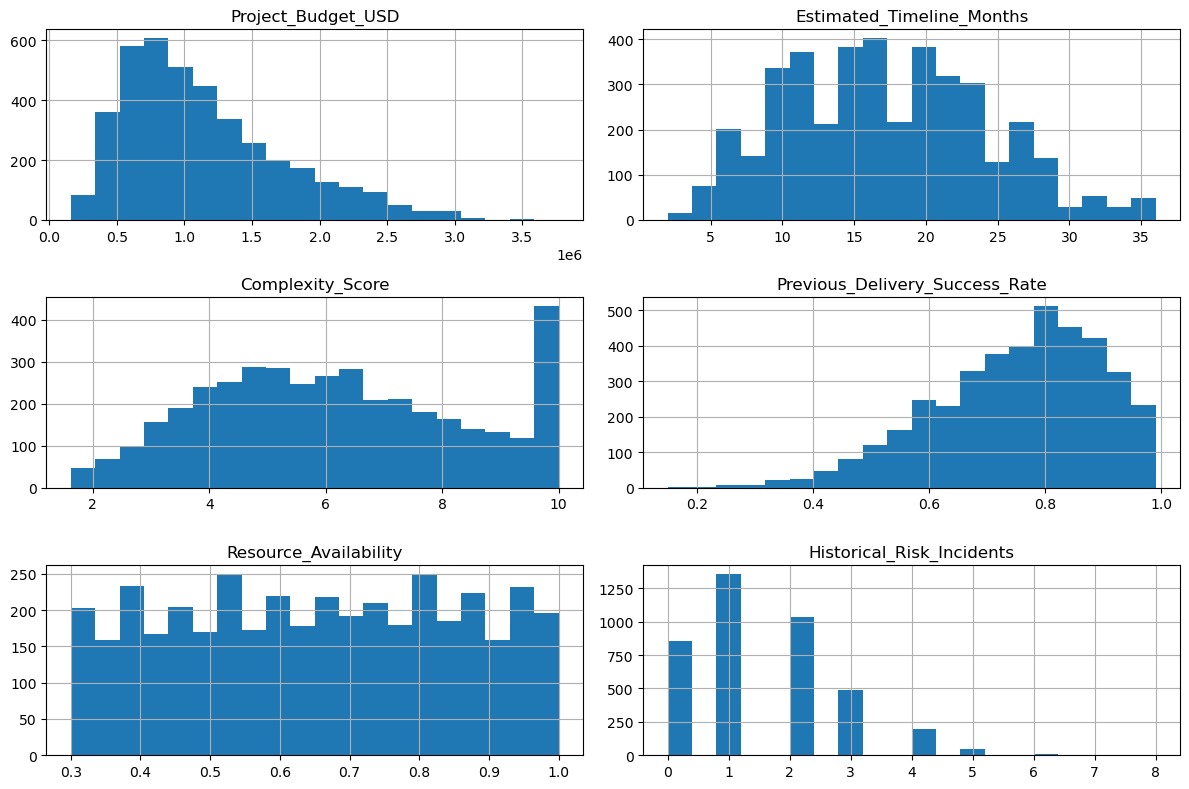

In [58]:
df[criteria_names].hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()

## 11. Analyze Criterion Correlations

The correlation matrix is used to identify relationships between the evaluation criteria.

These relationships provide additional context for interpreting the project data before applying the prioritization methods.

In [59]:
correlation_matrix = df[
    criteria_names
].corr()

correlation_matrix

,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Previous_Delivery_Success_Rate,Resource_Availability,Historical_Risk_Incidents
Project_Budget_USD,1.000000,0.863532,0.583238,-0.033817,0.001698,-0.011279
Estimated_Timeline_Months,0.863532,1.000000,0.792578,-0.045353,0.003268,-0.008789
Complexity_Score,0.583238,0.792578,1.000000,-0.038973,-0.004851,-0.012619
Previous_Delivery_Success_Rate,-0.033817,-0.045353,-0.038973,1.000000,0.016040,0.029849
Resource_Availability,0.001698,0.003268,-0.004851,0.016040,1.000000,-0.004475
Historical_Risk_Incidents,-0.011279,-0.008789,-0.012619,0.029849,-0.004475,1.000000


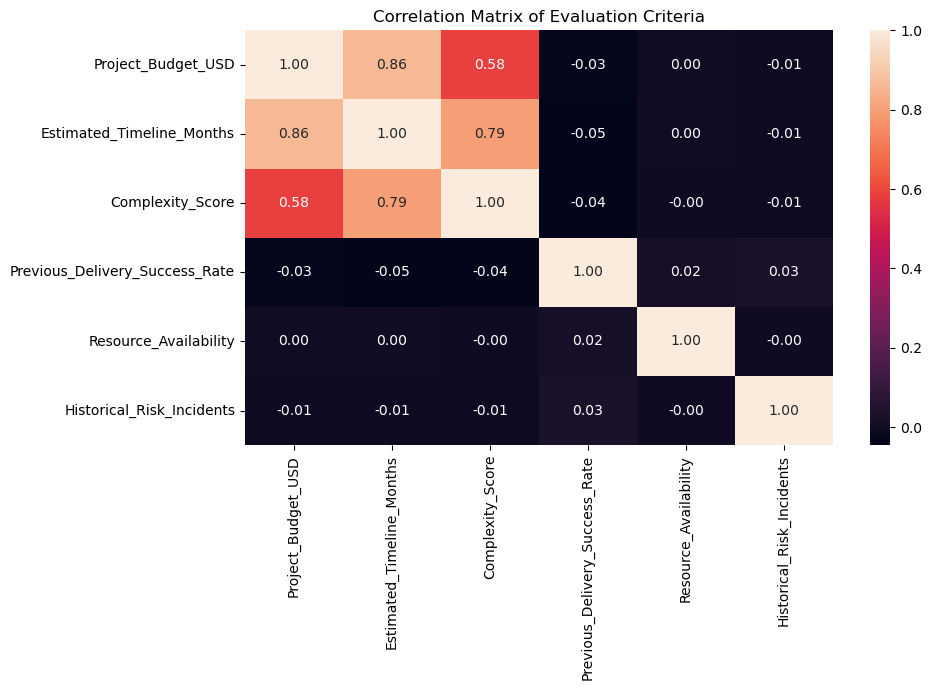

In [60]:
plt.figure(
    figsize=(10, 7)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Evaluation Criteria"
)

plt.tight_layout()
plt.show()

## 12. Compare Criteria by Objective

The selected criteria are classified according to whether higher or lower values are preferred in the prioritization model.

In [61]:
criteria_summary = pd.DataFrame({
    "Criterion": criteria_names,
    "Objective": [
        criteria_objectives[criterion]
        for criterion in criteria_names
    ]
})

criteria_summary

,Criterion,Objective
0,Project_Budget_USD,min
1,Estimated_Timeline_Months,min
2,Complexity_Score,min
3,Previous_Delivery_Success_Rate,max
4,Resource_Availability,max
5,Historical_Risk_Incidents,min


## 13. Validate the Analysis Dataset

The final validation confirms that the dataset contains the expected number of projects and that all selected evaluation criteria are available for the subsequent AHP analysis.

In [62]:
print(
    "Number of projects:",
    len(df)
)

print(
    "Number of selected criteria:",
    len(criteria_names)
)

print(
    "Missing values in selected criteria:",
    df[criteria_names].isna().sum().sum()
)

print(
    "Duplicated projects:",
    df["Project_ID"].duplicated().sum()
)

Number of projects: 4000
Number of selected criteria: 6
Missing values in selected criteria: 0
Duplicated projects: 0
